<a href="https://colab.research.google.com/github/EshikaAbbaraju/Role_Specified_Collective_Foraging_Task_Model/blob/main/Heatmaps_Formula_Based_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

!git clone https://github.com/JerryGuo2001/Role_Speficifed_Collective_Foraging_Task.git
#%cd Role_Speficifed_Collective_Foraging_Task
%cd /content/Role_Speficifed_Collective_Foraging_Task
CSV_DIR = "gridworld/"

os.makedirs("gifs", exist_ok=True)
os.makedirs("csv", exist_ok=True)

Cloning into 'Role_Speficifed_Collective_Foraging_Task'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 312 (delta 23), reused 42 (delta 12), pack-reused 255 (from 1)
Receiving objects: 100% (312/312), 3.35 MiB | 15.59 MiB/s, done.
Resolving deltas: 100% (171/171), done.
/content/Role_Speficifed_Collective_Foraging_Task


In [2]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass, replace
from typing import Dict, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import ListedColormap

def reward_observed(env: pd.DataFrame, pos: Tuple[int, int], revealed: Set[Tuple[int, int]]) -> float:
    if pos not in revealed or pos not in env.index:
        return 0.0
    return float(env.loc[pos, "reward_prob"])

def _mine_observed(env: pd.DataFrame, pos: Tuple[int, int], revealed: Set[Tuple[int, int]]) -> bool:
    if pos not in revealed or pos not in env.index:
        return False
    return str(env.loc[pos, "mine_type"]).strip() != ""

def load_env_from_csv(
    csv_path: str,
    prob_A: float = 0.8,
    prob_B: float = 0.5,
    prob_C: float = 0.2,
) -> pd.DataFrame:
    raw = pd.read_csv(csv_path)
    raw = raw.rename(columns={"x": "Row", "y": "Col", "mine_type": "mine_type", "alien_id": "alien_id"})
    rows = []
    for _, row in raw.iterrows():
        r, c = int(row["Row"]), int(row["Col"])
        mine_type = str(row["mine_type"]).strip() if not pd.isna(row["mine_type"]) else ""
        alien_val = row["alien_id"]

        if mine_type == "Gold Mine A":
            reward_prob, richness = prob_A, "high"
        elif mine_type == "Gold Mine B":
            reward_prob, richness = prob_B, "medium"
        elif mine_type == "Gold Mine C":
            reward_prob, richness = prob_C, "low"
        else:
            mine_type, reward_prob, richness = "", 0.0, "none"

        alien_level = 0 if (pd.isna(alien_val) or str(alien_val).strip() == "") else int(float(alien_val))
        rows.append({
            "Row": r,
            "Col": c,
            "Location": f"{r}:{c}",
            "mine_type": mine_type,
            "richness": richness,
            "reward_prob": float(reward_prob),
            "alien_level": alien_level,
        })
    env = pd.DataFrame(rows)
    env.set_index(["Row", "Col"], inplace=True, drop=False)
    return env


@dataclass
class ForagerConfig:
    moves_per_round: int = 5
    lambda_sec: float = 1.0
    mine_capacity_high: int = 8
    mine_capacity_medium: int = 5
    mine_capacity_low: int = 2
    security_pos: Optional[Tuple[int, int]] = None
    role_mode: str = "unknown"
    seed: Optional[int] = None


class ForagerAgent:
    def __init__(self, env: pd.DataFrame, cfg: ForagerConfig):
        self.env = env
        self.cfg = cfg
        self.revealed_cells: Set[Tuple[int, int]] = set()

        self.pos = (0,0)

        self.t = 0
        self.total_reward = 0.0
        self.round_reward = 0.0
        self.visited: Set[Tuple[int, int]] = {self.pos}
        self.stunned_rounds_remaining = 0
        self.stun_round_started = None
        self.alpha = 0
        self.w_t = 0.6 #risk parameter
        self.discount_factor = 2
        self.rng = np.random.default_rng(cfg.seed)


        self.logs: List[dict] = []
        self.frames_action: List[str] = []
        self.prev_pos: Optional[Tuple[int, int]] = None
        self.current_round: int = 0

        self.mine_remaining: Dict[Tuple[int, int], int] = {}
        self.initial_mine_remaining: Dict[Tuple[int, int], int] = {}
        for (r, c), row in self.env.iterrows():
            mt = str(row["mine_type"]).strip()
            if mt == "Gold Mine A":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_high)
            elif mt == "Gold Mine B":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_medium)
            elif mt == "Gold Mine C":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_low)
        self.mine_remaining = dict(self.initial_mine_remaining)

    def reveal_here(self) -> None:
        self.revealed_cells.add(tuple(self.pos))

    def current_reward_prob(self) -> float:
        if self.pos in self.mine_remaining and self.mine_remaining[self.pos] <= 0:
            return 0.0
        return reward_observed(self.env, self.pos, self.revealed_cells)

    def neighbors(self) -> List[Tuple[int, int]]:
        r, c = self.pos
        return [p for p in [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)] if p in self.env.index]

    def Vdig(self) -> float:
        return self.current_reward_prob()

    def Vmove(self) -> float:
        return self.round_reward / float(self.t) if self.t > 0 else 0.0

    def _active_dig_mines(self) -> List[Tuple[int, int]]:
        out: List[Tuple[int, int]] = []
        for p in self.revealed_cells:
            if p not in self.env.index or not _mine_observed(self.env, p, self.revealed_cells):
                continue
            if self.mine_remaining.get(p, 0) <= 0:
                continue
            if reward_observed(self.env, p, self.revealed_cells) <= 0.0:
                continue
            out.append(p)
        return out

    def E_exploit(self, s_prime: Tuple[int, int]) -> float:
        best = 0.0
        for p in self._active_dig_mines():
            rp = reward_observed(self.env, p, self.revealed_cells)
            d = abs(s_prime[0] - p[0]) + abs(s_prime[1] - p[1])
            d = max(1, float(d))
            best = max(best, rp / (float(d)))
        return best

    def E_explore(self, s_prime: Tuple[int, int]) -> float:
        best = 0.0
        unrevealed = [p for p in self.env.index if p not in self.revealed_cells]
        for p in unrevealed:
              d = abs(s_prime[0] - p[0]) + abs(s_prime[1] - p[1])
              d = max(1, float(d))
              best = max(best, 1 / (float(d)))
        return best

    def has_active_revealed_mine(self) -> bool:
        return len(self._active_dig_mines()) > 0

    def lambda_for_moves(self):
        lam = float(self.cfg.lambda_sec)
        rm = str(self.cfg.role_mode).lower()
        if lam < 0.0:
          rm = "follower"
        elif lam > 0.0:
          rm = "leader"
        return rm, lam

    def calculate_alpha(self, vd: float, vm: float) -> float:
        self.alpha = vd - vm
        return self.alpha

    def log(self, **kw):
        kw.setdefault("step", self.t)
        kw.setdefault("row", self.pos[0])
        kw.setdefault("col", self.pos[1])
        kw.setdefault("total_reward", self.total_reward)
        kw.setdefault("round_reward", self.round_reward)
        kw.setdefault("round", self.current_round)
        kw.setdefault("forager_role_mode", self.cfg.role_mode)
        kw.setdefault("alpha", self.alpha)
        self.logs.append(kw)

    def dig(self) -> float:
        r = self.current_reward_prob()
        self.total_reward += r
        self.round_reward += r
        if self.pos in self.mine_remaining and self.mine_remaining[self.pos] > 0:
            self.mine_remaining[self.pos] -= 1
        return r

    def A_goal(self, s_prime: Tuple[int, int], w: float) -> float:
        return ((1.0 - self.w_t) * self.E_exploit(s_prime)) + self.w_t * self.E_explore(s_prime)

    def exploration_reward(self, candidate_pos: Tuple[int, int], decay: float = 0.5) -> float:
      reward = 0.0

      for p in self.env.index:
          if p in self.revealed_cells:
              continue

          d = abs(candidate_pos[0] - p[0]) + abs(candidate_pos[1] - p[1])
          if d == 0:
              reward += 1.0
          else:
              reward += decay ** (d - 1)

      return reward

    def move_to_best_A(self, w: float) -> Tuple[bool, int]:

        scored = []

        nbrs = self.neighbors()
        if not nbrs:
            return False, 0
        rm, lam = self.lambda_for_moves()

        for p in nbrs:
            a = self.A_goal(p, w)
            if self.cfg.security_pos is None:
                d = 0
            else:
                d = abs(p[0] - self.cfg.security_pos[0]) + abs(p[1] - self.cfg.security_pos[1])
            revisit_discount = 1.0
            if p in self.revealed_cells:
                revisit_discount *= 0.5
            if p in self.visited:
                revisit_discount *= 0.35
            if self.prev_pos is not None and p == self.prev_pos:
                revisit_discount *= 0.02
            reward = self.exploration_reward(p, decay=0.5)
            A = self.discount_factor * (lam * d) + (a * revisit_discount) + reward

            scored.append((A, p))
        if not scored:
            return False, 0

        scores = [score for score, _ in scored]
        positions = [p for _, p in scored]

        probs = self.softmax_choice(scores)

        idx = self.rng.choice(len(positions), p=probs)
        best_p = positions[idx]

        self.pos = best_p

        self.visited.add(self.pos)
        self.reveal_here()
        al = int(self.env.loc[self.pos, "alien_level"])
        if (
            al > 0
        ):
            self.stunned_rounds_remaining = 4
            self.stun_round_started = self.current_round
        return True, al

    def softmax_choice(self, values, temperature=0.5):
        vals = np.array(values, dtype=float) / max(temperature, 1e-9)
        vals = vals - np.max(vals)
        probs = np.exp(vals) / np.sum(np.exp(vals))
        return probs

    def step(self, security_agent: SecurityAgent) -> str:
        pos_before = tuple(self.pos)
        self.reveal_here()

        if self.stunned_rounds_remaining > 0:

             self.log(action="stunned", decision="stunned", Vdig=np.nan, Vmove=np.nan, w=np.nan, alpha=np.nan)
             self.frames_action.append("stunned")
             self.t += 1
             self.prev_pos = pos_before
             return "stunned"

        vd, vm = self.Vdig(), self.Vmove()
        alpha_t = self.calculate_alpha(vd, vm)

        probs = self.softmax_choice([vd, vm])
        action = self.rng.choice(["dig", "move"], p=probs)

        if action == "dig":
            r_gained = self.dig()
            self.log(
                action="dig",
                decision="dig",
                Vdig=vd,
                Vmove=vm,
                w_t=self.w_t,
                r_gained=r_gained,
                position=tuple(self.pos),
                alpha=alpha_t,
            )
            self.frames_action.append("dig")
        else:
            moved, alien_lvl = self.move_to_best_A(self.w_t)
            self.log(
                action="move" if moved else "no_move",
                decision="move",
                Vdig=vd,
                Vmove=vm,
                w_t=self.w_t,
                alien_level=alien_lvl if alien_lvl else None,
                position=tuple(self.pos),
                alpha=alpha_t,
            )
            self.frames_action.append("move" if moved else "no_move")

        self.t += 1
        self.prev_pos = pos_before

        return self.frames_action[-1]

In [3]:

@dataclass
class SecurityConfig:
    gamma_lead: float = 10.0 #tunable, likelihood of being leader/tendency
    gamma_follow: float = 0.2 #tunable
    follow_radius: int = 3
    seed: Optional[int] = None
    chase_clear_radius: int = 3
    lambda_sec: float = 1.0
    mine_capacity_high: int = 8
    mine_capacity_medium: int = 5
    mine_capacity_low: int = 2

class SecurityAgent:
    def __init__(self, env, cfg: SecurityConfig, start_pos: Tuple[int, int]):
        self.env = env
        self.cfg = cfg
        self.allowed_steps = 5
        self.start_pos = start_pos
        self.pos = start_pos
        self.revealed_cells: Set[Tuple[int, int]] = set()
        self.epsilon = 0.92 #free parameter for v_chase
        self.w_t = 0.8 #risk param
        self.forager_pos: Optional[Tuple[int, int]] = None
        self.visited: Set[Tuple[int, int]] = {self.pos}
        self.frames_action: List[str] = []
        self.prev_security_pos: Optional[Tuple[int, int]] = None
        self.alien_threshold = 0.8
        self.role = "unknown"
        self.discount_factor = 2
        self.next_v_chase = 0.0
        self.next_v_move = 0.0
        self.next_alpha = 0.0
        self.rng = np.random.default_rng(cfg.seed)

        self.mine_remaining: Dict[Tuple[int, int], int] = {}
        self.initial_mine_remaining: Dict[Tuple[int, int], int] = {}
        for (r, c), row in self.env.iterrows():
            mt = str(row["mine_type"]).strip()
            if mt == "Gold Mine A":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_high)
            elif mt == "Gold Mine B":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_medium)
            elif mt == "Gold Mine C":
                self.initial_mine_remaining[(r, c)] = int(cfg.mine_capacity_low)
        self.mine_remaining = dict(self.initial_mine_remaining)

        rows = env.index.get_level_values(0)
        cols = env.index.get_level_values(1)

        min_r, max_r = int(rows.min()), int(rows.max())
        min_c, max_c = int(cols.min()), int(cols.max())

        self.Dmax = (max_r - min_r) + (max_c - min_c)

        self.logs: List[dict] = []
        self.alien_cells_cleared: Set[Tuple[int, int]] = set()
        self.gold_mine_cell_count: int = sum(
            1 for (_, row) in self.env.iterrows() if str(row["mine_type"]).strip() != ""
        )
        self.recent_positions: deque = deque([start_pos], maxlen=4)
        self.chased_spots: Set[Tuple[int, int]] = set()

    def count_revealed_gold_mines(self) -> int:
        n = 0
        for p in self.revealed_cells:
            if p not in self.env.index:
                continue
            if str(self.env.loc[p, "mine_type"]).strip() != "":
                n += 1
        return n

    def neighbors(self, pos: Optional[Tuple[int, int]] = None) -> List[Tuple[int, int]]:
        if pos is None:
            pos = self.pos
        r, c = pos
        return [p for p in [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)] if p in self.env.index]

    def distance(self, a: Tuple[int, int], b: Tuple[int, int]) -> int:
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def calculate_alpha(self, vc: float, vm: float) -> float:
        self.alpha = vc - vm
        return self.alpha

    def _active_dig_mines(self) -> List[Tuple[int, int]]:
        out: List[Tuple[int, int]] = []
        for p in self.revealed_cells:
            if p not in self.env.index or not _mine_observed(self.env, p, self.revealed_cells):
                continue
            if self.mine_remaining.get(p, 0) <= 0:
                continue
            if reward_observed(self.env, p, self.revealed_cells) <= 0.0:
                continue
            out.append(p)
        return out

    def E_exploit(self, s_prime: Tuple[int, int]) -> float:
        best = 0.0
        for p in self._active_dig_mines():
              rp = reward_observed(self.env, p, self.revealed_cells)
              d = abs(s_prime[0] - p[0]) + abs(s_prime[1] - p[1])
              d = max(1, float(d))
              best = max(best, rp / (float(d)))
        return best

    def E_explore(self, s_prime: Tuple[int, int]) -> float:
        best = 0.0
        unrevealed = [p for p in self.env.index if p not in self.revealed_cells]
        for p in unrevealed:
              d = abs(s_prime[0] - p[0]) + abs(s_prime[1] - p[1])
              d = max(1, float(d))
              best = max(best, 1 / (float(d)))
        return best

    def A_goal(self, s_prime: Tuple[int, int], w_t: float) -> float:
        return ((1.0 - self.w_t) * self.E_exploit(s_prime)) + self.w_t * self.E_explore(s_prime)

    def gold_mines_around(self, pos: Tuple[int, int]) -> float: #global
        score = 0.0
        for p in self.revealed_cells:
            if p not in self.env.index:
                continue
            if not _mine_observed(self.env, p, self.revealed_cells):
                continue

            reward = reward_observed(self.env, p, self.revealed_cells)
            d = abs(pos[0] - p[0]) + abs(pos[1] - p[1])
            d = max(1, float(d))
            score += reward / d
        return score

    def lambda_for_moves(self):
          lam = float(self.cfg.lambda_sec)
          rm = str(self.role).lower()

          if lam < 0.0:
              rm = "follower"

          elif lam > 0.0:
              rm = "leader"

          return rm, lam

    def exploration_reward(self, candidate_pos: Tuple[int, int], decay: float = 0.5) -> float:
        reward = 0.0

        for p in self.env.index:
            if p in self.revealed_cells:
                continue

            d = abs(candidate_pos[0] - p[0]) + abs(candidate_pos[1] - p[1])
            if d == 0:
                reward += 1.0
            else:
                reward += decay ** (d - 1)

        return reward


    def move_to_best_A(self, w_t: float) -> Tuple[bool, int]:
        scored = []
        nbrs = self.neighbors()
        if not nbrs:
            return False, 0

        rm, lam = self.lambda_for_moves()

        for p in nbrs:
            if p in self.chased_spots:
                continue
            a = self.A_goal(p, w_t)
            d = abs(p[0] - self.forager_pos[0]) + abs(p[1] - self.forager_pos[1])
            revisit_discount = 1.0
            if p in self.revealed_cells:
                revisit_discount *= 0.7
            if p in self.visited:
                revisit_discount *= 0.7

            reward = self.exploration_reward(p, decay=0.5)
            A = self.discount_factor*(lam * d) + (a * revisit_discount) + reward

            scored.append((A, p))
        if not scored:
            return False, 0

        scores = [score for score, _ in scored]
        positions = [p for _, p in scored]

        probs = self.softmax_choice(scores)

        idx = self.rng.choice(len(positions), p=probs)
        best_p = positions[idx]

        self.pos = best_p

        self.visited.add(self.pos)
        self.reveal_here()
        al = int(self.env.loc[self.pos, "alien_level"])
        return True, al

    def reveal_here(self) -> None:
        self.revealed_cells.add(tuple(self.pos))

    def register_chase_clearance(self) -> None:
      r0 = int(self.cfg.chase_clear_radius)
      for (r, c), row in self.env.iterrows():
          if int(row["alien_level"]) <= 0:
              continue
          if self.distance(self.pos, (r, c)) <= r0:
              self.alien_cells_cleared.add((r, c))
              self.env.loc[(r, c), "alien_level"] = 0
      self.chased_spots.add(tuple(self.pos))

    def step_toward(self, current_pos: Tuple[int, int], target_pos: Tuple[int, int]):
        nbrs = self.neighbors(current_pos)
        if not nbrs:
            return current_pos, False

        best_d = min(self.distance(p, target_pos) for p in nbrs)
        best = [p for p in nbrs if self.distance(p, target_pos) == best_d]
        new_pos = best[0]
        return new_pos, True

    def rescue_stunned(self, forager_agent):
      if forager_agent.stunned_rounds_remaining <= 0:
          return "no_rescue_needed"

      if self.pos == forager_agent.pos:
          forager_agent.stunned_rounds_remaining = 0
          return "rescued"

      self.pos, moved = self.step_toward(self.pos, forager_agent.pos)

      if self.pos == forager_agent.pos:
          forager_agent.stunned_rounds_remaining = 0
          return "rescued"

      return "move_rescue" if moved else "rescue_no_step"

    def alien_belief_at(self, pos: Tuple[int, int]) -> float:
        base_reward = reward_observed(self.env, pos, self.revealed_cells)
        return float(np.clip(0.35 + 0.65 * base_reward, 0.0, 1.0))

    def softmax_choice(self, values, temperature=1.0):
        vals = np.array(values, dtype=float) / max(temperature, 1e-9)
        vals = vals - np.max(vals)
        probs = np.exp(vals) / np.sum(np.exp(vals))
        return probs


    def step(
        self,
        t_in_round: int,
        forager_agent: ForagerAgent,
        round_idx: int,
        global_step: int,
        epsilon: int,
    ) -> Tuple[str, float]:
        self.reveal_here()
        prev_before_move = tuple(self.pos)
        self.forager_pos = tuple(forager_agent.pos)
        forager_pos = self.forager_pos

        revealed_count = len(self.revealed_cells)
        total_cells = len(self.env.index)
        stunned_total = sum(1 for x in forager_agent.frames_action if x == "stunned")

        self.role, _ = self.lambda_for_moves()

        p_alien_block = self.alien_belief_at(self.pos)
        n_gold_revealed = float(max(0, self.count_revealed_gold_mines()))
        v_chase = epsilon * p_alien_block
        gold_score = self.gold_mines_around(self.pos)
        inferred_forager_movement = gold_score * (1.0 - p_alien_block)
        v_move = inferred_forager_movement * p_alien_block
        alpha_before = self.calculate_alpha(v_chase, v_move)

        moved = False
        move_action = "idle"
        rescue_action = None
        should_consider_chase = p_alien_block > self.alien_threshold

        if forager_agent.stunned_rounds_remaining > 0:
            rescue_action = self.rescue_stunned(forager_agent)
            move_action = rescue_action
            moved = rescue_action in {"move_rescue", "rescued"}

        elif should_consider_chase:
            probs = self.softmax_choice([v_chase, v_move])
            action = self.rng.choice(["chase", "move"], p=probs)

            if action == "chase":
                if tuple(self.pos) not in self.chased_spots:
                  move_action = "chase_at_spot"
                  self.register_chase_clearance()
                else:
                  moved, alien_lvl = self.move_to_best_A(self.w_t)
                  move_action = "move" if moved else "no_move"

            else:
                moved, alien_lvl = self.move_to_best_A(self.w_t)
                move_action = "move" if moved else "no_move"

        else:
            moved, alien_lvl = self.move_to_best_A(self.w_t)
            move_action = "move" if moved else "no_move"


        self.logs.append({
            "global_step": global_step,
            "round": round_idx,
            "step_in_round": t_in_round,
            "security_prev_row": prev_before_move[0],
            "security_prev_col": prev_before_move[1],
            "security_row": self.pos[0],
            "security_col": self.pos[1],
            "security_move": move_action,
            "p_alien_belief": p_alien_block,
            "gold_mines_map_count": int(self.count_revealed_gold_mines()),
            "gold_mine_total_ground_truth": int(self.gold_mine_cell_count),
            "inferred_forager_movement": float(inferred_forager_movement),
            "Vmove_t": v_move,
            "Vchase_t": v_chase,
            "lead_weight": float(self.cfg.gamma_lead),
            "follow_weight": float(self.cfg.gamma_follow),
            "alpha": float(alpha_before)
        })

        self.visited.add(self.pos)
        self.reveal_here()
        revealed_count_after = len(self.revealed_cells)

        p_belief_after = self.alien_belief_at(self.pos)
        gold_score_after = self.gold_mines_around(self.pos)
        inferred_forager_movement_after = gold_score_after * (1.0 - p_belief_after)

        self.next_v_chase = epsilon * p_belief_after
        self.next_v_move = inferred_forager_movement_after * p_belief_after
        self.next_alpha = self.calculate_alpha(self.next_v_chase, self.next_v_move)

        self.recent_positions.append(tuple(self.pos))

        return move_action, v_chase

In [4]:
@dataclass
class AnimFrame:
    turn_idx: int
    phase: str
    step_in_phase: int
    global_step: int
    forager_pos: Tuple[int, int]
    security_pos: Tuple[int, int]
    forager_action: str
    security_move: str
    forager_role: str
    security_role: str
    vchase: float
    depleted: Set[Tuple[int, int]]
    forager_total_reward: float
    forager_round_reward: float
    revealed_cells: Set[Tuple[int, int]]
    is_start: bool = False


def run_foraging_simulation(
    csv_path: str,
    rounds: int = 3,
    forager_cfg: Optional[ForagerConfig] = None,
    security_cfg: Optional[SecurityConfig] = None,
    out_prefix: str = "forager",
    save_csv: bool = True,
    save_gif: bool = True,
) -> Dict[str, object]:
    env = load_env_from_csv(csv_path)

    max_r = int(env.index.get_level_values(0).max())
    max_c = int(env.index.get_level_values(1).max())
    start = (max_r // 2, max_c // 2)
    sec_start: Optional[Tuple[int, int]] = None
    for dr, dc in ((0, 1), (1, 0), (0, -1), (-1, 0)):
        p = (start[0] + dr, start[1] + dc)
        if p in env.index:
            sec_start = p
            break
    if sec_start is None:
        sec_start = start

    forager_cfg = forager_cfg or ForagerConfig()
    security_cfg = security_cfg or SecurityConfig()

    forager = ForagerAgent(env, forager_cfg)
    security = SecurityAgent(env, security_cfg, start_pos=sec_start)

    forager.pos = start
    forager.visited = {start}
    forager.cfg.security_pos = tuple(security.pos)

    revealed_cells: Set[Tuple[int, int]] = set()
    revealed_cells.add(start)
    revealed_cells.add(sec_start)
    forager.revealed_cells = revealed_cells
    security.revealed_cells = revealed_cells

    frames: List[AnimFrame] = []
    moves = forager_cfg.moves_per_round
    num_turn_rounds = rounds
    global_step = 0

    forager_role, _ = forager.lambda_for_moves()
    security_role, _ = security.lambda_for_moves()

    frames.append(
        AnimFrame(
            turn_idx=-1,
            phase="—",
            step_in_phase=-1,
            global_step=-1,
            forager_pos=tuple(forager.pos),
            security_pos=tuple(security.pos),
            forager_action="(start)",
            security_move="(start)",
            forager_role=forager_role,
            security_role=security_role,
            vchase=0.0,
            depleted=set(),
            forager_total_reward=forager.total_reward,
            forager_round_reward=forager.round_reward,
            revealed_cells=set(revealed_cells),
            is_start=True,
        )
    )

    for turn_idx in range(num_turn_rounds):
        forager_turn = (turn_idx % 2 == 0)
        forager.current_round = turn_idx

        if forager_turn:
            for k in range(moves):
                forager.cfg.security_pos = tuple(security.pos)
                fa = forager.step(security)
                depleted = {p for p, rem in forager.mine_remaining.items() if rem <= 0}

                security_role, _ = security.lambda_for_moves()
                forager_role, _ = forager.lambda_for_moves()

                frames.append(
                    AnimFrame(
                        turn_idx=turn_idx,
                        phase="forager",
                        step_in_phase=k,
                        global_step=global_step,
                        forager_pos=tuple(forager.pos),
                        security_pos=tuple(security.pos),
                        forager_action=fa,
                        security_move="(frozen)",
                        forager_role=forager_role,
                        security_role=security_role,
                        vchase=0.0,
                        depleted=set(depleted),
                        forager_total_reward=forager.total_reward,
                        forager_round_reward=forager.round_reward,
                        revealed_cells=set(revealed_cells),
                        is_start=False,
                    )
                )
                global_step += 1
            if forager.stunned_rounds_remaining > 0:
                forager.stunned_rounds_remaining -= 1
        else:
            for k in range(moves):
                security.step(
                    t_in_round=k,
                    forager_agent=forager,
                    round_idx=turn_idx,
                    global_step=global_step,
                    epsilon=security.epsilon,
                )
                sec_row = security.logs[-1]
                depleted = {p for p, rem in forager.mine_remaining.items() if rem <= 0}

                security_role, _ = security.lambda_for_moves()
                forager_role, _ = forager.lambda_for_moves()

                frames.append(
                    AnimFrame(
                        turn_idx=turn_idx,
                        phase="security",
                        step_in_phase=k,
                        global_step=global_step,
                        forager_pos=tuple(forager.pos),
                        security_pos=tuple(security.pos),
                        forager_action="(frozen)",
                        security_move=str(sec_row["security_move"]),
                        forager_role=forager_role,
                        security_role=security_role,
                        vchase=float(sec_row["Vchase_t"]),
                        depleted=set(depleted),
                        forager_total_reward=forager.total_reward,
                        forager_round_reward=forager.round_reward,
                        revealed_cells=set(revealed_cells),
                        is_start=False,
                    )
                )
                global_step += 1

    forager_log = pd.DataFrame(forager.logs)
    security_log = pd.DataFrame(security.logs)

    if save_csv:
        os.makedirs("csv", exist_ok=True)
        forager_log.to_csv(os.path.join("csv", f"{out_prefix}_forager.csv"), index=False)
        security_log.to_csv(os.path.join("csv", f"{out_prefix}_security.csv"), index=False)

    if save_gif:
        os.makedirs("gifs", exist_ok=True)
        animate_simulation(
            env,
            frames,
            num_turn_rounds=rounds,
            moves_per_round=forager_cfg.moves_per_round,
            outpath=os.path.join("gifs", f"{out_prefix}.gif"),
        )


    return {
        "env": env,
        "forager": forager,
        "security": security,
        "forager_log": forager_log,
        "security_log": security_log,
        "frames": frames,
        "total_reward": forager.total_reward,
        "rounds": rounds,
        "moves_per_round": forager_cfg.moves_per_round,
        "total_agent_steps": global_step,
        "revealed_cells": revealed_cells,
    }


def animate_simulation(
    env: pd.DataFrame,
    frames: List[AnimFrame],
    num_turn_rounds: int,
    moves_per_round: int,
    outpath: str = "forager.gif",
):
    env_idx = env.set_index(["Row", "Col"], drop=False)
    max_r, max_c = int(env_idx["Row"].max()), int(env_idx["Col"].max())

    base = np.zeros((max_r + 1, max_c + 1))
    for (r, c), row in env_idx.iterrows():
        base[r, c] = row["reward_prob"]

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color="lightgray")
    im = ax.imshow(base, cmap=cmap, origin="upper", vmin=0, vmax=1)

    depleted_cmap = ListedColormap(["#2a2a2a"])
    depleted_layer = np.ma.masked_all((max_r + 1, max_c + 1))
    im_depleted = ax.imshow(
        depleted_layer,
        cmap=depleted_cmap,
        vmin=0,
        vmax=1,
        origin="upper",
        zorder=2,
        interpolation="nearest",
    )

    fd, = ax.plot([], [], "o", color="tab:blue", markersize=11, markeredgecolor="white",
                  markeredgewidth=1.5, label="Forager", zorder=5)
    sd, = ax.plot([], [], "s", color="limegreen", markersize=10, markeredgecolor="black",
                  markeredgewidth=1.2, label="Security", zorder=6)

    ax.set_xticks(range(max_c + 1))
    ax.set_yticks(range(max_r + 1))
    ax.grid(True, linestyle=":", alpha=0.3)
    ax.legend(loc="upper right")

    def _depleted_mine_layer(depleted: Set[Tuple[int, int]]):
        z = np.ma.masked_all((max_r + 1, max_c + 1))
        for (r, c) in depleted:
            if (r, c) not in env_idx.index:
                continue
            if str(env_idx.loc[(r, c), "mine_type"]).strip() == "":
                continue
            z[r, c] = 1.0
        return z

    def init():
        im.set_data(base)
        if frames:
            f0 = frames[0]
            g = base.astype(float).copy()
            rev = f0.revealed_cells
            for r in range(max_r + 1):
                for c in range(max_c + 1):
                    if (r, c) not in env_idx.index:
                        continue
                    if (r, c) not in rev:
                        g[r, c] = np.nan
            im.set_data(g)
            im_depleted.set_data(_depleted_mine_layer(f0.depleted))
            r0, c0 = f0.forager_pos
            rs, cs = f0.security_pos
            if (r0, c0) == (rs, cs):
                r0p, rsp = r0 - 0.22, rs + 0.22
            else:
                r0p, rsp = r0, rs
            fd.set_data([c0], [r0p])
            sd.set_data([cs], [rsp])
        else:
            fd.set_data([], [])
            sd.set_data([], [])
        ax.set_title("")
        return [im, im_depleted, fd, sd]

    def update(i):
        fr = frames[i]
        g = base.astype(float).copy()
        rev = fr.revealed_cells

        for dr, dc in fr.depleted:
            g[dr, dc] = np.nan

        for r in range(max_r + 1):
            for c in range(max_c + 1):
                if (r, c) not in env_idx.index:
                    continue
                if (r, c) not in rev:
                    g[r, c] = np.nan

        im.set_data(g)
        im_depleted.set_data(_depleted_mine_layer(fr.depleted))

        frg, fcg = fr.forager_pos
        sr, sc = fr.security_pos
        if (frg, fcg) == (sr, sc):
            frg_plot, sr_plot = frg - 0.22, sr + 0.22
        else:
            frg_plot, sr_plot = frg, sr

        fd.set_data([fcg], [frg_plot])
        sd.set_data([sc], [sr_plot])

        gstep = "—" if fr.global_step < 0 else str(fr.global_step + 1)
        stext = "—" if fr.step_in_phase < 0 else f"{fr.step_in_phase + 1}/{moves_per_round}"

        if fr.is_start:
            title = (
                f"Alternating rounds: each round = {moves_per_round} steps by ONE agent (no world reset)\n"
                f"INITIAL | global step {gstep} | next: ROUND 1 = FORAGER x{moves_per_round}\n"
                f"Forager: {fr.forager_action} | {fr.forager_role}\n"
                f"Security: {fr.security_move} ({fr.security_role})\n"
                f"Reward total={fr.forager_total_reward:.3f} round_reward={fr.forager_round_reward:.3f} | "
                f"revealed {len(fr.revealed_cells)}/{len(env_idx)} cells"
            )
        else:
            if fr.phase == "forager":
                active = "FORAGER moving"
                sec_extra = ""
            elif fr.phase == "security":
                active = "SECURITY moving"
                sec_extra = f" | Vchase={fr.vchase:.3f}"
            else:
                active = str(fr.phase)
                sec_extra = ""

            frozen_note = "other agent frozen" if fr.phase in ("forager", "security") else ""
            title = (
                f"ROUND {fr.turn_idx + 1}/{num_turn_rounds} | {active} | step {stext} | global {gstep} | {frozen_note}\n"
                f"Forager: {fr.forager_action} | {fr.forager_role}\n"
                f"Security: {fr.security_move} ({fr.security_role}){sec_extra}\n"
                f"Reward total={fr.forager_total_reward:.3f} round_reward={fr.forager_round_reward:.3f} | "
                f"revealed {len(fr.revealed_cells)}/{len(env_idx)} cells"
            )

        ax.set_title(title, fontsize=9)
        return [im, im_depleted, fd, sd]

    anim = FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(frames),
        interval=450,
        blit=False,
        repeat=True,
    )
    anim.save(outpath, writer=PillowWriter(fps=3))
    plt.close(fig)

In [5]:
!unzip -o gridworld/final_generated_maps.zip -d gridworld/final_generated_maps

Archive:  gridworld/final_generated_maps.zip
   creating: gridworld/final_generated_maps/.config/
  inflating: gridworld/final_generated_maps/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db  
  inflating: gridworld/final_generated_maps/.config/default_configs.db  
 extracting: gridworld/final_generated_maps/.config/config_sentinel  
   creating: gridworld/final_generated_maps/.config/configurations/
  inflating: gridworld/final_generated_maps/.config/configurations/config_default  
 extracting: gridworld/final_generated_maps/.config/.last_survey_prompt.yaml  
   creating: gridworld/final_generated_maps/.config/logs/
   creating: gridworld/final_generated_maps/.config/logs/2026.04.16/
  inflating: gridworld/final_generated_maps/.config/logs/2026.04.16/13.28.22.950479.log  
  inflating: gridworld/final_generated_maps/.config/logs/2026.04.16/13.27.53.684484.log  
  inflating: gridworld/final_generated_maps/.config/logs/2026.04.16/13.28.21.827521.log  
  inflating: g

In [9]:
CSV_DIR = "gridworld/final_generated_maps"


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# 1. Run / resume lambda sweep
# ---------------------------------
lambda_values = np.round(np.arange(-1.0, 1.01, 0.5), 1)

results_path = "lambda_sweep_rewards_all_grids.csv"

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    done = set(
        zip(
            results_df["grid"],
            results_df["forager_lambda"].round(1),
            results_df["security_lambda"].round(1),
        )
    )
    results = results_df.to_dict("records")
else:
    done = set()
    results = []

grid_csvs = [
    os.path.join(CSV_DIR, f)
    for f in os.listdir(CSV_DIR)
    if f.endswith(".csv")
]

for grid_path in grid_csvs:
    grid_name = os.path.splitext(os.path.basename(grid_path))[0]

    # assign group from filename
    if "middle_reward_middle_risk" in grid_name:
        risk_group = "middle"
    elif "low_reward_low_risk" in grid_name:
        risk_group = "low"
    elif "high_reward_high_risk" in grid_name:
        risk_group = "high"
    else:
        risk_group = "other"

    for forager_lambda in lambda_values:
        for security_lambda in lambda_values:
            key = (grid_name, float(forager_lambda), float(security_lambda))

            if key in done:
                print("Skipping done:", key)
                continue

            out_prefix = (
                f"{grid_name}_"
                f"forager_lambda_{forager_lambda:+.1f}_"
                f"security_lambda_{security_lambda:+.1f}"
            )
            out_prefix = (
                out_prefix
                .replace("+", "pos")
                .replace("-", "neg")
                .replace(".", "p")
            )

            print("Running:", out_prefix)

            out = run_foraging_simulation(
                grid_path,
                rounds=10,
                forager_cfg=ForagerConfig(
                    moves_per_round=5,
                    lambda_sec=float(forager_lambda),
                    seed=0,
                ),
                security_cfg=SecurityConfig(
                    lambda_sec=float(security_lambda),
                    seed=0,
                ),
                out_prefix=out_prefix,
                save_csv=True,
                save_gif=True,
            )

            row = {
                "grid": grid_name,
                "risk_group": risk_group,
                "forager_lambda": float(forager_lambda),
                "security_lambda": float(security_lambda),
                "total_reward": out["total_reward"],
            }

            results.append(row)
            done.add(key)

            pd.DataFrame(results).to_csv(results_path, index=False)

print("Finished sweep / resume.")
print("Saved results to:", results_path)

Running: middle_reward_middle_risk_10_forager_lambda_neg1p0_security_lambda_neg1p0
Running: middle_reward_middle_risk_10_forager_lambda_neg1p0_security_lambda_neg0p5
Running: middle_reward_middle_risk_10_forager_lambda_neg1p0_security_lambda_pos0p0
Running: middle_reward_middle_risk_10_forager_lambda_neg1p0_security_lambda_pos0p5
Running: middle_reward_middle_risk_10_forager_lambda_neg1p0_security_lambda_pos1p0
Running: middle_reward_middle_risk_10_forager_lambda_neg0p5_security_lambda_neg1p0
Running: middle_reward_middle_risk_10_forager_lambda_neg0p5_security_lambda_neg0p5
Running: middle_reward_middle_risk_10_forager_lambda_neg0p5_security_lambda_pos0p0
Running: middle_reward_middle_risk_10_forager_lambda_neg0p5_security_lambda_pos0p5
Running: middle_reward_middle_risk_10_forager_lambda_neg0p5_security_lambda_pos1p0
Running: middle_reward_middle_risk_10_forager_lambda_pos0p0_security_lambda_neg1p0
Running: middle_reward_middle_risk_10_forager_lambda_pos0p0_security_lambda_neg0p5
Runn

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


Running: low_reward_low_risk_07_forager_lambda_neg0p5_security_lambda_pos0p0
Running: low_reward_low_risk_07_forager_lambda_neg0p5_security_lambda_pos0p5
Running: low_reward_low_risk_07_forager_lambda_neg0p5_security_lambda_pos1p0
Running: low_reward_low_risk_07_forager_lambda_pos0p0_security_lambda_neg1p0
Running: low_reward_low_risk_07_forager_lambda_pos0p0_security_lambda_neg0p5
Running: low_reward_low_risk_07_forager_lambda_pos0p0_security_lambda_pos0p0
Running: low_reward_low_risk_07_forager_lambda_pos0p0_security_lambda_pos0p5
Running: low_reward_low_risk_07_forager_lambda_pos0p0_security_lambda_pos1p0
Running: low_reward_low_risk_07_forager_lambda_pos0p5_security_lambda_neg1p0
Running: low_reward_low_risk_07_forager_lambda_pos0p5_security_lambda_neg0p5
Running: low_reward_low_risk_07_forager_lambda_pos0p5_security_lambda_pos0p0
Running: low_reward_low_risk_07_forager_lambda_pos0p5_security_lambda_pos0p5
Running: low_reward_low_risk_07_forager_lambda_pos0p5_security_lambda_pos1p0

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


Running: low_reward_low_risk_09_forager_lambda_pos0p0_security_lambda_neg0p5
Running: low_reward_low_risk_09_forager_lambda_pos0p0_security_lambda_pos0p0
Running: low_reward_low_risk_09_forager_lambda_pos0p0_security_lambda_pos0p5
Running: low_reward_low_risk_09_forager_lambda_pos0p0_security_lambda_pos1p0
Running: low_reward_low_risk_09_forager_lambda_pos0p5_security_lambda_neg1p0
Running: low_reward_low_risk_09_forager_lambda_pos0p5_security_lambda_neg0p5
Running: low_reward_low_risk_09_forager_lambda_pos0p5_security_lambda_pos0p0
Running: low_reward_low_risk_09_forager_lambda_pos0p5_security_lambda_pos0p5
Running: low_reward_low_risk_09_forager_lambda_pos0p5_security_lambda_pos1p0
Running: low_reward_low_risk_09_forager_lambda_pos1p0_security_lambda_neg1p0
Running: low_reward_low_risk_09_forager_lambda_pos1p0_security_lambda_neg0p5
Running: low_reward_low_risk_09_forager_lambda_pos1p0_security_lambda_pos0p0
Running: low_reward_low_risk_09_forager_lambda_pos1p0_security_lambda_pos0p5

...

Running: low_reward_low_risk_02_forager_lambda_neg1p0_security_lambda_pos1p0
Running: low_reward_low_risk_02_forager_lambda_neg0p5_security_lambda_neg1p0


/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


Running: low_reward_low_risk_02_forager_lambda_neg0p5_security_lambda_neg0p5
Running: low_reward_low_risk_02_forager_lambda_neg0p5_security_lambda_pos0p0
Running: low_reward_low_risk_02_forager_lambda_neg0p5_security_lambda_pos0p5
Running: low_reward_low_risk_02_forager_lambda_neg0p5_security_lambda_pos1p0
Running: low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_neg1p0
Running: low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_neg0p5
Running: low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_pos0p0
Running: low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_pos0p5
Running: low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_pos1p0
Running: low_reward_low_risk_02_forager_lambda_pos0p5_security_lambda_neg1p0
Running: low_reward_low_risk_02_forager_lambda_pos0p5_security_lambda_neg0p5
Running: low_reward_low_risk_02_forager_lambda_pos0p5_security_lambda_pos0p0
Running: low_reward_low_risk_02_forager_lambda_pos0p5_security_lambda_pos0p5

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


Running: middle_reward_middle_risk_09_forager_lambda_pos0p5_security_lambda_neg1p0
Running: middle_reward_middle_risk_09_forager_lambda_pos0p5_security_lambda_neg0p5
Running: middle_reward_middle_risk_09_forager_lambda_pos0p5_security_lambda_pos0p0
Running: middle_reward_middle_risk_09_forager_lambda_pos0p5_security_lambda_pos0p5
Running: middle_reward_middle_risk_09_forager_lambda_pos0p5_security_lambda_pos1p0
Running: middle_reward_middle_risk_09_forager_lambda_pos1p0_security_lambda_neg1p0
Running: middle_reward_middle_risk_09_forager_lambda_pos1p0_security_lambda_neg0p5
Running: middle_reward_middle_risk_09_forager_lambda_pos1p0_security_lambda_pos0p0
Running: middle_reward_middle_risk_09_forager_lambda_pos1p0_security_lambda_pos0p5
Running: middle_reward_middle_risk_09_forager_lambda_pos1p0_security_lambda_pos1p0
Finished sweep / resume.
Saved results to: lambda_sweep_rewards_all_grids.csv


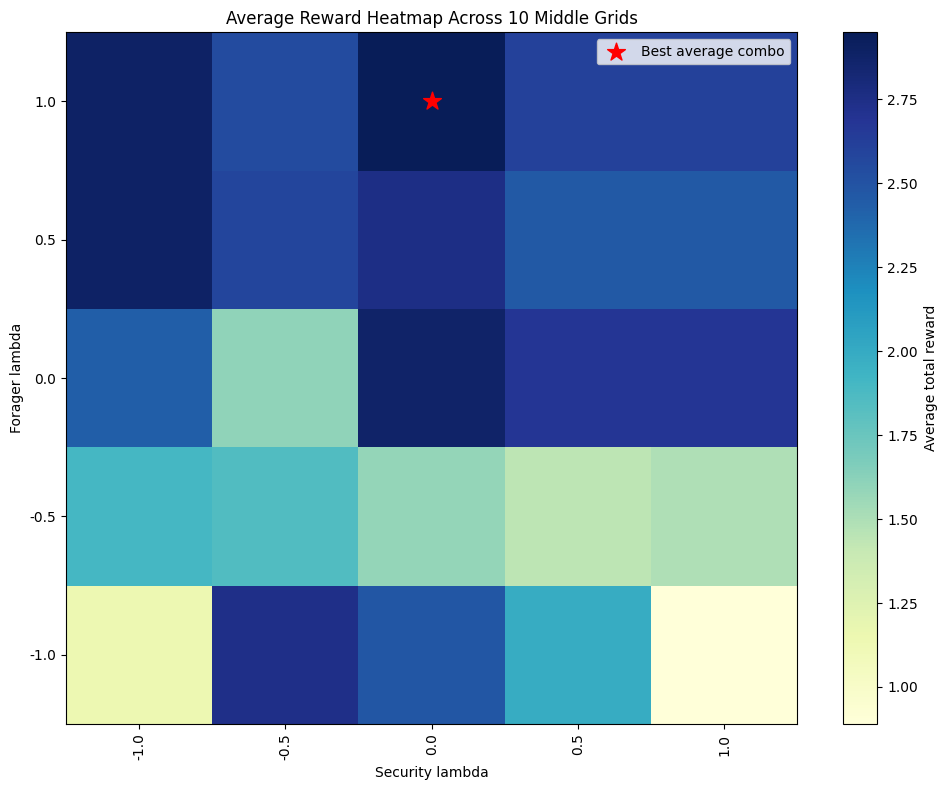

Middle best avg combo -> Forager lambda: 1.0, Security lambda: 0.0, Avg reward: 2.950


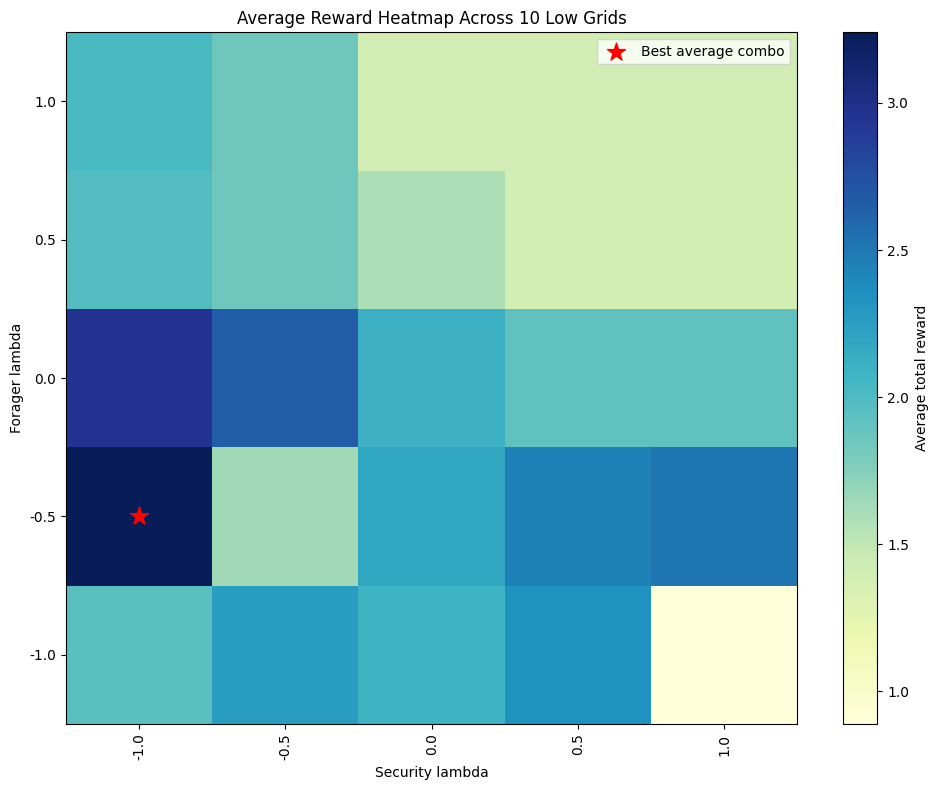

Low best avg combo -> Forager lambda: -0.5, Security lambda: -1.0, Avg reward: 3.240


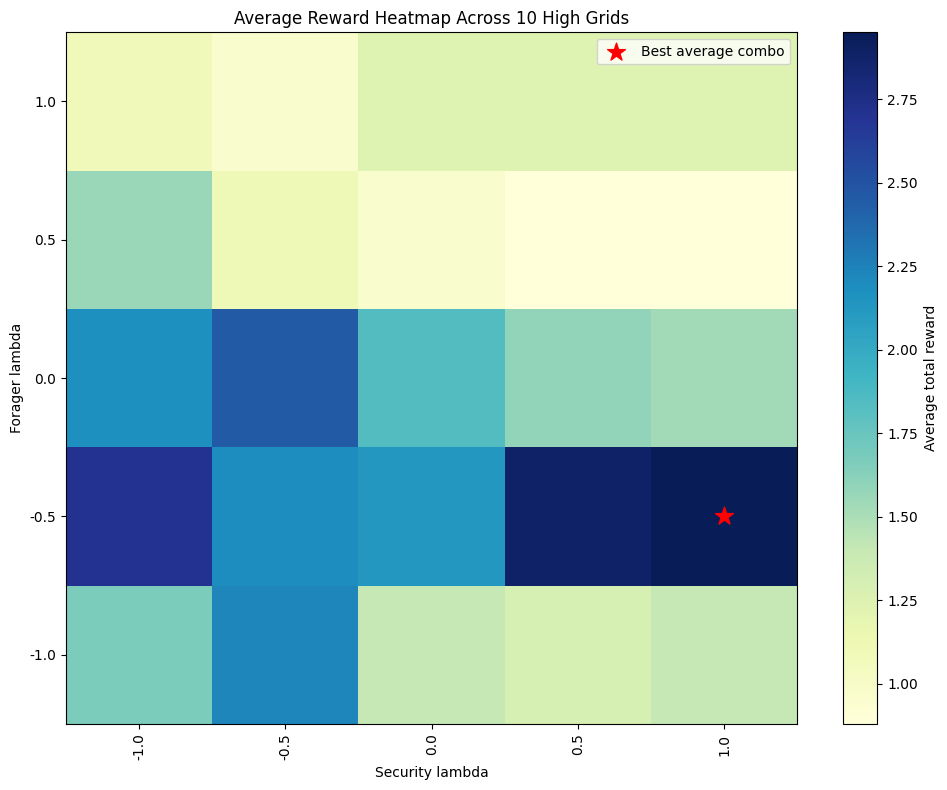

High best avg combo -> Forager lambda: -0.5, Security lambda: 1.0, Avg reward: 2.950
Saved average group heatmaps to: avg_lambda_heatmaps/


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv(results_path)

os.makedirs("avg_lambda_heatmaps", exist_ok=True)

for group in ["middle", "low", "high"]:
    group_df = results_df[results_df["risk_group"] == group].copy()

    if group_df.empty:
        print(f"No rows found for group: {group}")
        continue

    avg_df = (
        group_df
        .groupby(["forager_lambda", "security_lambda"], as_index=False)["total_reward"]
        .mean()
    )

    heat = avg_df.pivot(
        index="forager_lambda",
        columns="security_lambda",
        values="total_reward",
    )

    plt.figure(figsize=(10, 8))
    im = plt.imshow(heat, origin="lower", cmap="YlGnBu", aspect="auto")
    plt.colorbar(im, label="Average total reward")

    plt.xticks(
        ticks=np.arange(len(heat.columns)),
        labels=[f"{x:.1f}" for x in heat.columns],
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(len(heat.index)),
        labels=[f"{y:.1f}" for y in heat.index],
    )

    plt.xlabel("Security lambda")
    plt.ylabel("Forager lambda")
    plt.title(f"Average Reward Heatmap Across 10 {group.capitalize()} Grids")

    best = avg_df.loc[avg_df["total_reward"].idxmax()]
    x_idx = list(heat.columns).index(best["security_lambda"])
    y_idx = list(heat.index).index(best["forager_lambda"])

    plt.scatter(
        x_idx,
        y_idx,
        color="red",
        marker="*",
        s=180,
        label="Best average combo",
    )
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"avg_lambda_heatmaps/{group}_average_lambda_heatmap.png", dpi=200)
    plt.show()

    print(
        f"{group.capitalize()} best avg combo -> "
        f"Forager lambda: {best['forager_lambda']}, "
        f"Security lambda: {best['security_lambda']}, "
        f"Avg reward: {best['total_reward']:.3f}"
    )

print("Saved average group heatmaps to: avg_lambda_heatmaps/")

In [14]:
!git status
!git add csv gifs lambda_heatmaps avg_lambda_heatmaps lambda_sweep_rewards_all_grids.csv
!git commit -m "Add simulation outputs and lambda heatmaps"
!git push

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    gridworld/middle_reward_middle_risk_01.csv
	deleted:    gridworld/middle_reward_middle_risk_02.csv
	deleted:    gridworld/middle_reward_middle_risk_03.csv
	deleted:    gridworld/middle_reward_middle_risk_04.csv
	deleted:    gridworld/middle_reward_middle_risk_05.csv
	deleted:    gridworld/middle_reward_middle_risk_06.csv
	deleted:    gridworld/middle_reward_middle_risk_07.csv
	deleted:    gridworld/middle_reward_middle_risk_08.csv
	deleted:    gridworld/middle_reward_middle_risk_09.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	avg_lambda_heatmaps/
	csv/
	gifs/
	gridworld/final_generated_maps.zip
	gridworld/final_generated_maps/
	lambda_sweep_rewards_all_grids.csv

no changes added to commit (use "git add" a

In [15]:
!git clone https://github.com/EshikaAbbaraju/Role_Specified_Collective_Foraging_Task_Model.git

Cloning into 'Role_Specified_Collective_Foraging_Task_Model'...
remote: Enumerating objects: 386, done.
remote: Counting objects: 100% (386/386), done.
remote: Compressing objects: 100% (213/213), done.
remote: Total 386 (delta 207), reused 308 (delta 170), pack-reused 0 (from 0)
Receiving objects: 100% (386/386), 7.44 MiB | 22.86 MiB/s, done.
Resolving deltas: 100% (207/207), done.


In [16]:
%cd /content/Role_Specified_Collective_Foraging_Task_Model

[Errno 2] No such file or directory: '/content/Role_Specified_Collective_Foraging_Task_Model'
/content/Role_Speficifed_Collective_Foraging_Task


In [17]:
!ls /content


Role_Speficifed_Collective_Foraging_Task  sample_data


In [18]:
%cd /content/Role_Speficifed_Collective_Foraging_Task


/content/Role_Speficifed_Collective_Foraging_Task


In [19]:
!cp -r /content/Role_Speficifed_Collective_Foraging_Task/csv /content/Role_Specified_Collective_Foraging_Task_Model/
!cp -r /content/Role_Speficifed_Collective_Foraging_Task/gifs /content/Role_Specified_Collective_Foraging_Task_Model/
!cp -r /content/Role_Speficifed_Collective_Foraging_Task/lambda_heatmaps /content/Role_Specified_Collective_Foraging_Task_Model/
!cp -r /content/Role_Speficifed_Collective_Foraging_Task/avg_lambda_heatmaps /content/Role_Specified_Collective_Foraging_Task_Model/
!cp -r /content/Role_Speficifed_Collective_Foraging_Task/gridworld /content/Role_Specified_Collective_Foraging_Task_Model/
!cp /content/Role_Speficifed_Collective_Foraging_Task/lambda_sweep_rewards_all_grids.csv /content/Role_Specified_Collective_Foraging_Task_Model/


cp: cannot stat '/content/Role_Speficifed_Collective_Foraging_Task/lambda_heatmaps': No such file or directory


In [30]:
%cd /content/Role_Speficifed_Collective_Foraging_Task/Role_Specified_Collective_Foraging_Task_Model
!git status

/content/Role_Speficifed_Collective_Foraging_Task/Role_Specified_Collective_Foraging_Task_Model
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [36]:
%cd /content/Role_Speficifed_Collective_Foraging_Task

!zip -r simulation_outputs.zip csv gifs lambda_heatmaps avg_lambda_heatmaps
from google.colab import files
files.download("simulation_outputs.zip")


/content/Role_Speficifed_Collective_Foraging_Task
	zip warning: name not matched: lambda_heatmaps
updating: csv/ (stored 0%)
updating: csv/high_reward_high_risk_07_forager_lambda_pos0p0_security_lambda_neg1p0_security.csv (deflated 69%)
updating: csv/high_reward_high_risk_10_forager_lambda_pos1p0_security_lambda_pos0p0_security.csv (deflated 69%)
updating: csv/high_reward_high_risk_03_forager_lambda_pos0p5_security_lambda_pos0p0_security.csv (deflated 71%)
updating: csv/high_reward_high_risk_02_forager_lambda_pos0p0_security_lambda_pos0p5_security.csv (deflated 68%)
updating: csv/high_reward_high_risk_03_forager_lambda_pos0p0_security_lambda_neg1p0_forager.csv (deflated 75%)
updating: csv/high_reward_high_risk_04_forager_lambda_pos1p0_security_lambda_pos0p0_security.csv (deflated 69%)
updating: csv/high_reward_high_risk_09_forager_lambda_neg0p5_security_lambda_pos1p0_security.csv (deflated 70%)
updating: csv/low_reward_low_risk_02_forager_lambda_pos0p0_security_lambda_pos0p0_security.c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
